> **Versão pública (2026).** Notebook de outubro de 2022, rodado de novo em outubro de 2026, fora do Colab, com as coordenadas oficiais do TSE (notebook 01). O código é o original, com as mudanças listadas no [README](../README.md#sobre-esta-versão); os índices locais ganharam nomes neutros. As saídas são as de 2026.

In [1]:
import os
import shutil

import pandas as pd
import numpy as np
import geopandas as gpd

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import matplotlib.ticker as mtick

from matplotlib.animation import FuncAnimation, PillowWriter

from IPython.display import clear_output

In [2]:
PASTA_DO_PROJETO = '..'  # raiz do repositório

# Lê Dados das Votações por Seção Eleitoral

In [3]:
#Arquivos baixados do site do TSE
#https://dadosabertos.tse.jus.br/dataset/resultados-2022
#https://dadosabertos.tse.jus.br/dataset/resultados-2022-boletim-de-urna

#Outra Opção de Fonte:
#https://basedosdados.org/dataset/br-tse-eleicoes?bdm_table=resultados_candidato_secao

path_dados = f'{PASTA_DO_PROJETO}/dados_votacao'
lista_arquivos = ['detalhe_votacao_secao_2022.zip', 'votacao_secao_2022_BR.zip']
print(lista_arquivos)

path_dados_boletim = f'{PASTA_DO_PROJETO}/dados_boletim_urna'
lista_arquivos_boletim = os.listdir(path_dados_boletim)
print(len(lista_arquivos_boletim))

path_dados_geocodificacao = f'{PASTA_DO_PROJETO}/dados_coordenadas_zonas'
lista_arquivos_geo = os.listdir(path_dados_geocodificacao)
print(lista_arquivos_geo)

['detalhe_votacao_secao_2022.zip', 'votacao_secao_2022_BR.zip']
28
['coordenadas_zonas_eleitorais_2022.csv']


In [4]:
#Descompacta os arquivos
for arq in lista_arquivos:
    pasta = arq.split('.')[0]
    shutil.unpack_archive(f'{path_dados}/{arq}', pasta)

In [5]:
def leitura_dados(pasta, arq_csv, colunas):
    #Lê só as colunas usadas, para caber na memória
    return pd.read_csv(f'{pasta}/{arq_csv}', sep = ';', engine = 'c', encoding = 'latin-1', usecols = colunas)

arq = 'detalhe_votacao_secao_2022.zip'
pasta = arq.split('.')[0]
arq_csv = [f for f in os.listdir(pasta) if f.find('.csv') != -1 and f.find('_BRASIL') != -1][0]
df_desc_inp = leitura_dados(pasta, arq_csv, ['NR_TURNO', 'DS_CARGO', 'SG_UF', 'NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO',
                                             'QT_APTOS', 'QT_COMPARECIMENTO', 'QT_ABSTENCOES', 'QT_VOTOS_NOMINAIS',
                                             'QT_VOTOS_BRANCOS', 'QT_VOTOS_NULOS'])

arq = 'votacao_secao_2022_BR.zip'
pasta = arq.split('.')[0]
arq_csv = [f for f in os.listdir(pasta) if f.find('.csv') != -1][0]
df_inp = leitura_dados(pasta, arq_csv, ['NR_TURNO', 'DS_CARGO', 'SG_UF', 'NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO',
                                       'NM_VOTAVEL', 'QT_VOTOS'])

In [6]:
def trata_detalhe(df_desc_inp):
    df_desc = df_desc_inp[(df_desc_inp['DS_CARGO'] == 'PRESIDENTE') & (df_desc_inp['NR_TURNO'] == 1)]
    cols_id = ['SG_UF', 'NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO']
    cols_info = ['QT_APTOS', 'QT_COMPARECIMENTO', 'QT_ABSTENCOES', 'QT_VOTOS_NOMINAIS', 'QT_VOTOS_BRANCOS', 'QT_VOTOS_NULOS']
    df_desc = df_desc[np.append(cols_id, cols_info)].reset_index(drop = True)
    return df_desc.reset_index().rename({'index': 'ID_URNA'}, axis = 1).copy()

def trata_votacao(df_inp, df_desc):
    df = df_inp[(df_inp['DS_CARGO'] == 'PRESIDENTE') & (df_inp['NR_TURNO'] == 1)]
    cols_id = ['SG_UF', 'NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO', 'NM_VOTAVEL']
    cols_info = ['QT_VOTOS']
    df = df[np.append(cols_id, cols_info)].reset_index(drop = True).copy()
    cols_urna = ['ID_URNA', 'SG_UF', 'NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO']
    return pd.merge(df, df_desc[cols_urna], how = 'left', on = ['SG_UF', 'NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO'])

In [7]:
df_desc = trata_detalhe(df_desc_inp)
df_desc.sample(n = 5).T

,331058,423393,271375,230381,9621
ID_URNA,331058,423393,271375,230381,9621
SG_UF,RJ,MG,CE,SP,PA
NM_MUNICIPIO,DUQUE DE CAXIAS,SANTOS DUMONT,FORTALEZA,SÃO PAULO,MARABÁ
NR_ZONA,128,250,2,348,100
NR_SECAO,12,35,719,270,100
QT_APTOS,398,273,356,388,341
QT_COMPARECIMENTO,270,196,310,332,282
QT_ABSTENCOES,128,77,46,56,59
QT_VOTOS_NOMINAIS,262,192,298,317,269
QT_VOTOS_BRANCOS,2,3,5,5,3


In [8]:
df = trata_votacao(df_inp, df_desc)
df.sample(n = 5).T

,1880421,3226255,1768603,1665616,1731717
SG_UF,PA,SP,PE,MG,AM
NM_MUNICIPIO,MUANÁ,IBIÚNA,BOM CONSELHO,GOVERNADOR VALADARES,MANAUS
NR_ZONA,10,191,61,118,31
NR_SECAO,70,7,160,80,612
NM_VOTAVEL,KELMON LUIS DA SILVA SOUZA,JAIR MESSIAS BOLSONARO,CIRO FERREIRA GOMES,CIRO FERREIRA GOMES,CIRO FERREIRA GOMES
QT_VOTOS,1,141,4,4,5
ID_URNA,424958,404801,330696,19948,223457


In [9]:
df_geocod = pd.read_csv(f'{path_dados_geocodificacao}/coordenadas_zonas_eleitorais_2022.csv')
df_geocod = df_geocod.rename({'sigla_uf': 'SG_UF', 'numero_zona': 'NR_ZONA'}, axis = 1)
df_geocod = df_geocod[['SG_UF', 'NR_ZONA', 'Latitude', 'Longitude']]

gdf_geocod = gpd.GeoDataFrame(df_geocod, 
                            geometry = gpd.points_from_xy(df_geocod['Longitude'], df_geocod['Latitude']))

gdf_geocod.sample(n = 5).T

,2606,1167,401,148,1881
SG_UF,TO,PA,CE,BA,RO
NR_ZONA,4,65,89,29,2
Latitude,-8.057962,-1.5178,-3.346449,-14.84877,-8.745191
Longitude,-48.481723,-48.651547,-39.799264,-39.56845,-63.881433
geometry,POINT (-48.481723 -8.057962),POINT (-48.651547 -1.5178),POINT (-39.799264 -3.346449),POINT (-39.56845 -14.84877),POINT (-63.881433 -8.745191)


In [10]:
path_malhas = f'{PASTA_DO_PROJETO}/dados_malhas_ibge'
gdf_pais = gpd.read_file(f'{path_malhas}/BR_Pais_2021.zip')

#Encontra os pontos que cairam dentro do Brasil
contorno_convex = gdf_pais['geometry'].iloc[0].convex_hull
mask_interior = gdf_geocod['geometry'].apply(lambda p: p.within(contorno_convex))

gdf_geocod = gdf_geocod[mask_interior]

In [11]:
gdf_desc = pd.merge(df_desc, gdf_geocod, how = 'left', on = ['SG_UF', 'NR_ZONA'])

gdf_desc.sample(n = 5).T

,260690,434837,351053,347553,454287
ID_URNA,260690,434837,351053,347553,454287
SG_UF,PE,RS,RJ,SP,PR
NM_MUNICIPIO,CABO DE SANTO AGOSTINHO,PELOTAS,SÃO GONÇALO,TATUÍ,TERRA RICA
NR_ZONA,121,164,36,140,105
NR_SECAO,212,239,621,366,10
QT_APTOS,207,381,535,372,345
QT_COMPARECIMENTO,169,299,345,234,254
QT_ABSTENCOES,38,82,190,138,91
QT_VOTOS_NOMINAIS,162,287,332,204,243
QT_VOTOS_BRANCOS,0,5,2,7,3


# Resultados da Eleição

In [12]:
df_res = df[['NM_VOTAVEL', 'QT_VOTOS']].groupby('NM_VOTAVEL').sum().sort_values('QT_VOTOS', ascending = False)
df_res['PERC_VOTOS'] = df_res['QT_VOTOS']*100/df_res['QT_VOTOS'].sum()
df_res['PERC_VOTOS_VALIDOS'] = df_res['QT_VOTOS']*100/df_res.loc[~df_res.index.isin(['VOTO NULO', 'VOTO BRANCO']), 'QT_VOTOS'].sum()
display(df_res)

,QT_VOTOS,PERC_VOTOS,PERC_VOTOS_VALIDOS
NM_VOTAVEL,,,
LUIZ INÁCIO LULA DA SILVA,57259504,46.295606,48.430720
JAIR MESSIAS BOLSONARO,51072345,41.293148,43.197553
SIMONE NASSAR TEBET,4915423,3.974231,4.157519
CIRO FERREIRA GOMES,3599287,2.910105,3.044317
VOTO NULO,3487874,2.820025,2.950082
VOTO BRANCO,1964779,1.588568,1.661832
SORAYA VIEIRA THRONICKE,600955,0.485886,0.508294
LUIZ FELIPE CHAVES D AVILA,559708,0.452537,0.473407
KELMON LUIS DA SILVA SOUZA,81129,0.065595,0.068620


# Tratamento de Pontos com Mau Geolocalização

In [13]:
mask_sem_geoloc = gdf_desc['geometry'].isna()
gdf_desc_sem_geoloc = gdf_desc[mask_sem_geoloc].copy()

gdf_preencher = gdf_desc.loc[mask_sem_geoloc, ['SG_UF', 'NM_MUNICIPIO']].drop_duplicates()

In [14]:
path_malhas = f'{PASTA_DO_PROJETO}/dados_malhas_ibge'
gdf_mun = gpd.read_file(f'{path_malhas}/BR_Municipios_2021.zip')
gdf_mun['NM_MUNICIPIO'] = gdf_mun['NM_MUN'].str.upper()
gdf_mun['SG_UF'] = gdf_mun['SIGLA'].str.upper()
gdf_mun['geometry'] = gdf_mun['geometry'].centroid
gdf_mun = gdf_mun[['SG_UF', 'NM_MUNICIPIO', 'geometry']]

gdf_preencher = pd.merge(gdf_preencher, gdf_mun, how = 'left', on = ['SG_UF', 'NM_MUNICIPIO'])

<célula>:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_mun['geometry'] = gdf_mun['geometry'].centroid


In [15]:
#Escolhe a Zona Eleitoral geolocalizada dentro do Brasil mais próxima da Cidade

def f(x, gdf_geocod):
    dist = gdf_geocod['geometry'].distance(x)
    point_min = gdf_geocod.loc[dist == dist.min(), 'geometry'].iloc[0]
    return point_min

gdf_preencher['geometry'] = gdf_preencher['geometry'].apply(lambda x: f(x, gdf_geocod))
gdf_preencher['Longitude'] = gdf_preencher['geometry'].apply(lambda p: p.x)
gdf_preencher['Latitude'] = gdf_preencher['geometry'].apply(lambda p: p.y)

gdf_preencher = gdf_preencher[['SG_UF', 'NM_MUNICIPIO', 'Latitude', 'Longitude', 'geometry']]

In [16]:
gdf_desc_sem_geoloc = pd.merge(gdf_desc_sem_geoloc.drop(['Latitude', 'Longitude', 'geometry'], axis = 1),
                               gdf_preencher, how = 'left', on = ['SG_UF', 'NM_MUNICIPIO'])

In [17]:
gdf_desc = pd.concat([gdf_desc[~mask_sem_geoloc], gdf_desc_sem_geoloc]).sort_values('ID_URNA')

<célula>:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  gdf_desc = pd.concat([gdf_desc[~mask_sem_geoloc], gdf_desc_sem_geoloc]).sort_values('ID_URNA')


In [18]:
del gdf_pais, gdf_mun

# Análise por Geolocalização

In [19]:
df_geo = pd.merge(df[df['SG_UF'] != 'ZZ'], gdf_desc[['ID_URNA', 'Latitude', 'Longitude']], how = 'left', on = 'ID_URNA')

cols = ['Latitude', 'Longitude', 'NM_VOTAVEL', 'QT_VOTOS']
df_geo_agg = df_geo[cols].groupby(['Latitude', 'Longitude', 'NM_VOTAVEL']).sum().reset_index()

In [20]:
df_geo_pivot = df_geo_agg.pivot(index = ['Latitude', 'Longitude'], columns = ['NM_VOTAVEL'], values = 'QT_VOTOS')
df_geo_pivot = df_geo_pivot.fillna(0)
candidatos = list(df_geo_pivot.columns)
df_geo_pivot = df_geo_pivot.reset_index()

series_tot = df_geo_pivot[candidatos].sum(axis = 1)
for col in candidatos:
    df_geo_pivot[col] = df_geo_pivot[col]/series_tot

In [21]:
gdf = gpd.GeoDataFrame(df_geo_pivot[np.append(['Latitude', 'Longitude'], candidatos)], 
                       geometry = gpd.points_from_xy(df_geo_pivot['Longitude'], df_geo_pivot['Latitude']))
gdf = gdf.set_crs('epsg:4326')
gdf = gdf.to_crs(crs = 3857) #distância medida em metros

In [22]:
def f(gdf, dist, candidatos, row):
    df_temp = gdf[candidatos].copy()
    for candidato in candidatos:
        df_temp[candidato] = (df_temp[candidato] - row[candidato])**2
    df_temp['Delta'] = df_temp[candidatos].sum(axis = 1)**0.5/(2**0.5)
    df_temp['Distancia'] = dist
    df_temp['Latitude'] = row['Latitude']
    df_temp['Longitude'] = row['Longitude']
    return df_temp[['Latitude', 'Longitude', 'Distancia', 'Delta']]

lista_df = []
count = 0
tot = gdf.shape[0]
for ind, row in gdf.iterrows():
    dist = gdf['geometry'].distance(row['geometry'])/1000
    lista_df.append(f(gdf, dist, candidatos, row))

    clear_output(wait = True)
    count = count + 1
    perc = round(count*100/tot, 2)
    print(f'{count}/{tot} ({perc}%)')

2630/2630 (100.0%)


In [23]:
df_analise = pd.concat(lista_df)
df_analise = df_analise[df_analise['Distancia'] > 0]
df_analise

NM_VOTAVEL,Latitude,Longitude,Distancia,Delta
1,-33.523604,-53.363023,128.164550,0.052223
2,-33.523604,-53.363023,173.654145,0.020132
3,-33.523604,-53.363023,236.215797,0.018930
4,-33.523604,-53.363023,241.379677,0.021417
5,-33.523604,-53.363023,248.440637,0.068591
...,...,...,...,...
2624,4.441894,-61.130809,223.478511,0.148134
2625,4.441894,-61.130809,187.505738,0.164291
2626,4.441894,-61.130809,186.841647,0.182386
2627,4.441894,-61.130809,163.050407,0.127934


In [24]:
bins = np.unique(np.percentile(df_analise['Distancia'], np.arange(0, 100)))
df_analise['Bin'] = np.digitize(df_analise['Distancia'], bins)

In [25]:
def f_agg(x):
    d = {}
    d['Qtd'] = x.shape[0]
    d['Distancia'] = np.percentile(x['Distancia'], 50)
    d['Delta_Q1'] = np.percentile(x['Delta'], 25)
    d['Delta_Q2'] = np.percentile(x['Delta'], 50)
    d['Delta_Q3'] = np.percentile(x['Delta'], 75)
    return pd.Series(d)

df_analise_dist = df_analise.groupby('Bin').apply(lambda x: f_agg(x))
df_analise_dist = df_analise_dist[df_analise_dist['Qtd'] > df_analise_dist['Qtd'].mean()/2]

<célula>:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_analise_dist = df_analise.groupby('Bin').apply(lambda x: f_agg(x))


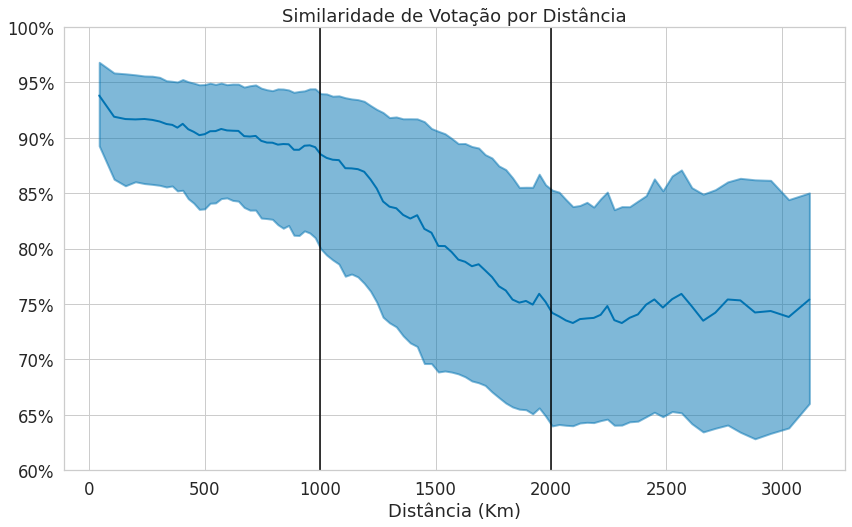

In [26]:
df_plot = df_analise_dist[df_analise_dist['Distancia'] <= 3200]

paleta_cores = sns.color_palette("colorblind")
with sns.axes_style("whitegrid"), sns.plotting_context('notebook', font_scale = 1.5):
    fig, ax = plt.subplots(1, 1, figsize = (14, 8))
    q1 = (1 - df_plot['Delta_Q1'])*100
    q2 = (1 - df_plot['Delta_Q2'])*100
    q3 = (1 - df_plot['Delta_Q3'])*100
    ax.fill_between(df_plot['Distancia'], q1, q3,
                    alpha = 0.5, 
                    lw = 2, color = paleta_cores[0])
    ax.plot(df_plot['Distancia'], q2, lw = 2, color = paleta_cores[0])
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals = 0))
    ax.set_ylim(bottom = 60, top = 100)
    ax.axvline(1000, color = 'black')
    ax.axvline(2000, color = 'black')
    ax.set_xlabel('Distância (Km)')
    ax.set_title('Similaridade de Votação por Distância')
    plt.show()

In [27]:
def f_agg(x):
    d = {}
    y = x[x['Distancia'] <= 500]
    d['Qtd'] = y.shape[0]
    d['Delta_Q1'] = np.percentile(y['Delta'], 25)
    d['Delta_Q2'] = np.percentile(y['Delta'], 50)
    d['Delta_Q3'] = np.percentile(y['Delta'], 75)
    return pd.Series(d)

df_analise_local = df_analise.groupby(['Latitude', 'Longitude']).apply(lambda x: f_agg(x))
df_analise_local['Semelhanca_Local'] = (1 - df_analise_local['Delta_Q3'])*100
df_analise_local['Variacao_Local'] = df_analise_local['Delta_Q1']*100
df_analise_local = df_analise_local.reset_index()

gdf_local = gpd.GeoDataFrame(df_analise_local, 
                             geometry = gpd.points_from_xy(df_analise_local['Longitude'], df_analise_local['Latitude']))
gdf_local = gdf_local.set_crs('epsg:4326')
gdf_local = gdf_local.to_crs(crs = 3857) #distância medida em metros

<célula>:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_analise_local = df_analise.groupby(['Latitude', 'Longitude']).apply(lambda x: f_agg(x))


In [28]:
path_malhas = f'{PASTA_DO_PROJETO}/dados_malhas_ibge'
#gdf_setor = gpd.read_file(f'{path_malhas}/BR_Setores_2020.zip')
gdf_mun = gpd.read_file(f'{path_malhas}/BR_Municipios_2021.zip')
gdf_uf = gpd.read_file(f'{path_malhas}/BR_UF_2021.zip')
gdf_pais = gpd.read_file(f'{path_malhas}/BR_Pais_2021.zip')

In [29]:
#Expande os valores mais próximos do contorno para os pontos de contorno
df_expand = pd.DataFrame(np.array(gdf_pais.convex_hull.boundary.iloc[0].coords), columns = ['Longitude', 'Latitude'])
gdf_expand = gpd.GeoDataFrame(df_expand, geometry = gpd.points_from_xy(df_expand['Longitude'], df_expand['Latitude']))
def f(x, gdf_local, candidatos):
    dist = gdf_local['geometry'].distance(x)
    cols = ['Qtd', 'Delta_Q1', 'Delta_Q2', 'Delta_Q3', 'Semelhanca_Local', 'Variacao_Local']
    ret = gdf_local.loc[dist == dist.min(), cols].mean(axis = 0)
    return ret
gdf_expand = pd.concat([gdf_expand, gdf_expand['geometry'].apply(lambda x: f(x, gdf_local, candidatos))], axis = 1)

#Adiciona os pontos de contorno expandidos
gdf_plot = pd.concat([gdf_local, gdf_expand])

<site-packages>/geopandas/array.py:1638: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as WGS 84 / Pseudo-Mercator (the single non-null crs provided).
  return GeometryArray(data, crs=_get_common_crs(to_concat))


In [30]:
gdf_contorno = gdf_pais
gdf_contorno_interno = gdf_uf

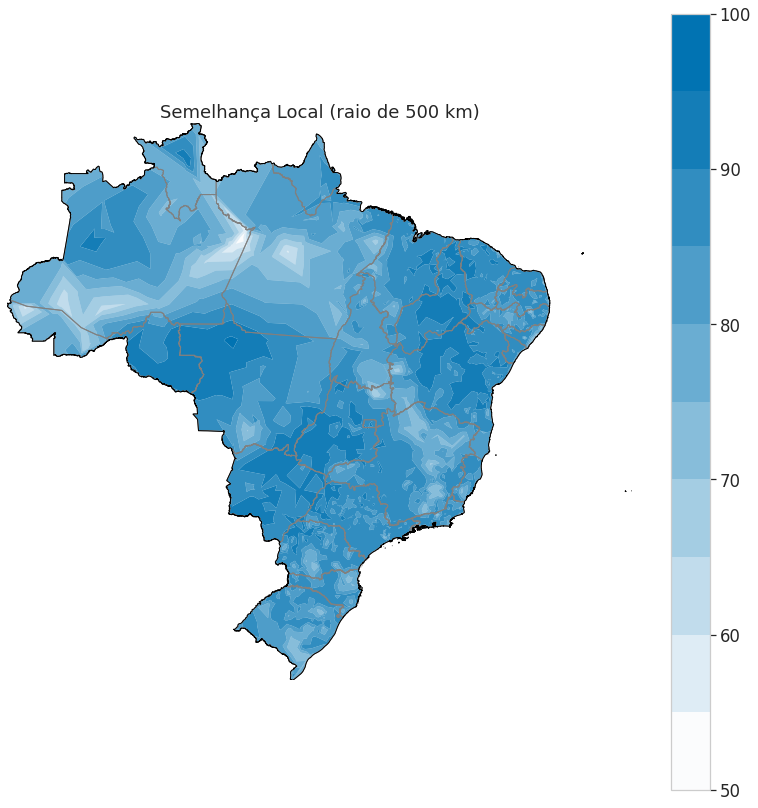

In [31]:
paleta_cores = sns.color_palette("colorblind")
with sns.axes_style("whitegrid"), sns.plotting_context('notebook', font_scale = 1.5):
    fig, ax = plt.subplots(1, 1, figsize = (14, 14))

    x = gdf_plot['Longitude']
    y = gdf_plot['Latitude']
    z = gdf_plot['Semelhanca_Local']

    N = 256
    cor = paleta_cores[0]
    vals = np.ones((N, 4))
    vals[:, 0] = cor[0]
    vals[:, 1] = cor[1]
    vals[:, 2] = cor[2]
    vals[:, 3] = np.linspace(0, 1, N)[::-1]
    cmap = mpl.colors.ListedColormap(vals[::-1])

    cntr = ax.tricontourf(x, y, z, levels = 10, 
                          cmap = cmap,
                          norm = mpl.colors.Normalize(vmin = z.min(), vmax = z.max(), clip = False),
                          linestyles = None, 
                          antialiased = True)
    cbar = plt.colorbar(cntr)
    
    #Limites do gráfico
    df_lim = pd.DataFrame(np.array(gdf_contorno.convex_hull.boundary.iloc[0].coords), columns = ['Longitude', 'Latitude'])
    ax.set_xlim([df_lim['Longitude'].min(), df_lim['Longitude'].max()])
    ax.set_ylim([df_lim['Latitude'].min(), df_lim['Latitude'].max()])
    #Contornos internos
    gdf_contorno_interno['geometry'].boundary.plot(ax = ax, color = 'grey', lw = 1)
    #Contornos externos
    (gdf_contorno['geometry'].envelope.difference(gdf_contorno['geometry'])).plot(ax = ax, color = 'white', edgecolor = None)
    gdf_contorno['geometry'].boundary.plot(ax = ax, color = 'black', lw = 1)
    #Remoção de Grades e Eixos
    ax.grid(False)
    frame = plt.gca()
    frame.axes.xaxis.set_ticklabels([])
    frame.axes.yaxis.set_ticklabels([])

    #ax.legend(handles = hlds, bbox_to_anchor = (1.0, 1), loc = 'upper left')
    ax.set_title('Semelhança Local (raio de 500 km)')

    plt.box(False)
    plt.show()

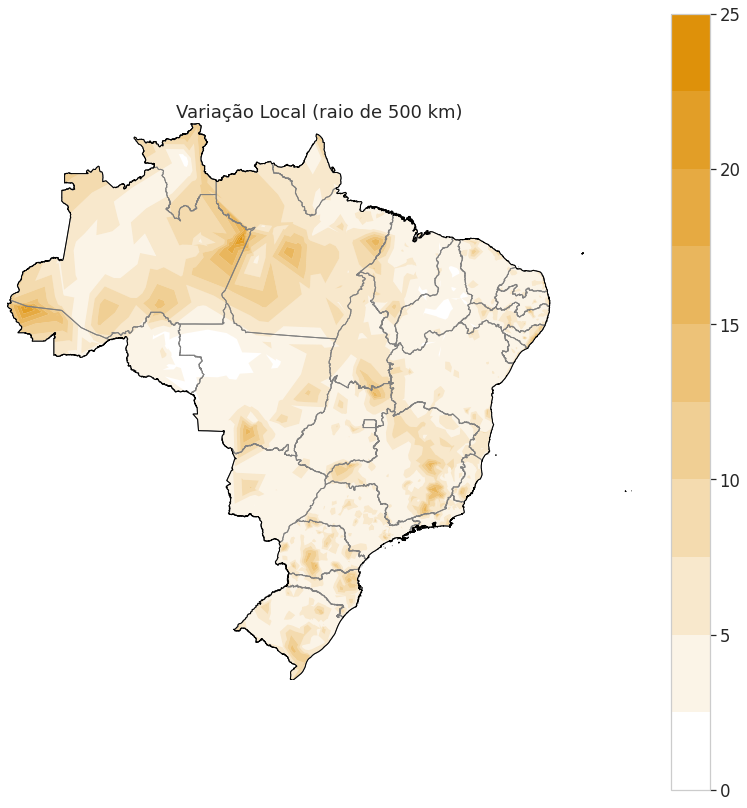

In [32]:
paleta_cores = sns.color_palette("colorblind")
with sns.axes_style("whitegrid"), sns.plotting_context('notebook', font_scale = 1.5):
    fig, ax = plt.subplots(1, 1, figsize = (14, 14))

    x = gdf_plot['Longitude']
    y = gdf_plot['Latitude']
    z = gdf_plot['Variacao_Local']

    N = 256
    cor = paleta_cores[1]
    vals = np.ones((N, 4))
    vals[:, 0] = cor[0]
    vals[:, 1] = cor[1]
    vals[:, 2] = cor[2]
    vals[:, 3] = np.linspace(0, 1, N)[::-1]
    cmap = mpl.colors.ListedColormap(vals[::-1])

    cntr = ax.tricontourf(x, y, z, levels = 10, 
                          cmap = cmap,
                          norm = mpl.colors.Normalize(vmin = z.min(), vmax = z.max(), clip = False),
                          linestyles = None, 
                          antialiased = True)
    cbar = plt.colorbar(cntr)
    
    #Limites do gráfico
    df_lim = pd.DataFrame(np.array(gdf_contorno.convex_hull.boundary.iloc[0].coords), columns = ['Longitude', 'Latitude'])
    ax.set_xlim([df_lim['Longitude'].min(), df_lim['Longitude'].max()])
    ax.set_ylim([df_lim['Latitude'].min(), df_lim['Latitude'].max()])
    #Contornos internos
    gdf_contorno_interno['geometry'].boundary.plot(ax = ax, color = 'grey', lw = 1)
    #Contornos externos
    (gdf_contorno['geometry'].envelope.difference(gdf_contorno['geometry'])).plot(ax = ax, color = 'white', edgecolor = None)
    gdf_contorno['geometry'].boundary.plot(ax = ax, color = 'black', lw = 1)
    #Remoção de Grades e Eixos
    ax.grid(False)
    frame = plt.gca()
    frame.axes.xaxis.set_ticklabels([])
    frame.axes.yaxis.set_ticklabels([])

    #ax.legend(handles = hlds, bbox_to_anchor = (1.0, 1), loc = 'upper left')
    ax.set_title('Variação Local (raio de 500 km)')

    plt.box(False)
    plt.show()

In [33]:
uf = 'SP'
gdf_contorno = gdf_uf[gdf_uf['SIGLA'] == uf]
gdf_contorno_interno = gdf_mun[gdf_mun['SIGLA'] == uf]

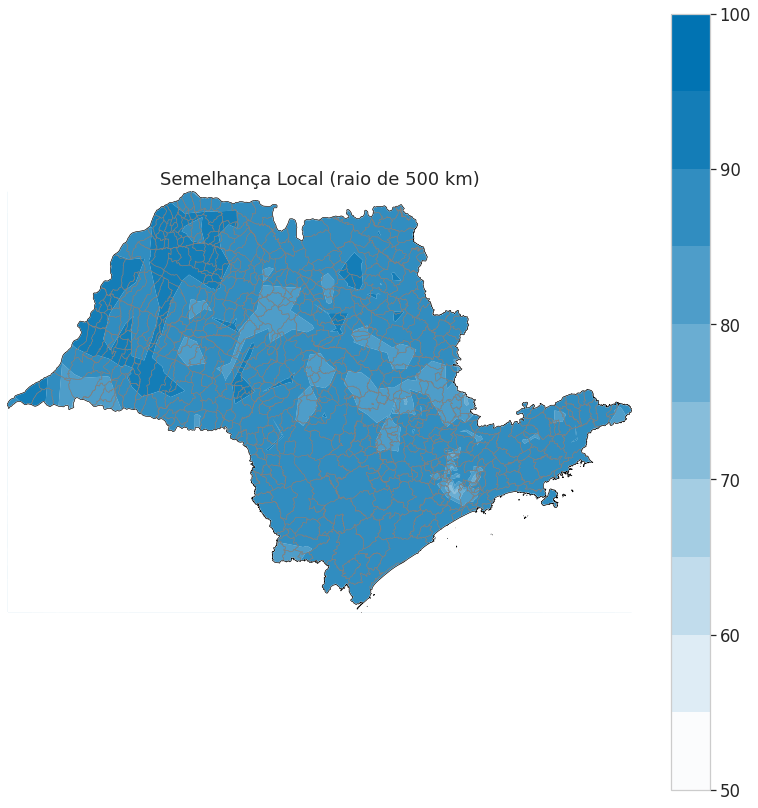

In [34]:
paleta_cores = sns.color_palette("colorblind")
with sns.axes_style("whitegrid"), sns.plotting_context('notebook', font_scale = 1.5):
    fig, ax = plt.subplots(1, 1, figsize = (14, 14))

    x = gdf_plot['Longitude']
    y = gdf_plot['Latitude']
    z = gdf_plot['Semelhanca_Local']

    N = 256
    cor = paleta_cores[0]
    vals = np.ones((N, 4))
    vals[:, 0] = cor[0]
    vals[:, 1] = cor[1]
    vals[:, 2] = cor[2]
    vals[:, 3] = np.linspace(0, 1, N)[::-1]
    cmap = mpl.colors.ListedColormap(vals[::-1])

    cntr = ax.tricontourf(x, y, z, levels = 10, 
                          cmap = cmap,
                          norm = mpl.colors.Normalize(vmin = z.min(), vmax = z.max(), clip = False),
                          linestyles = None, 
                          antialiased = True)
    cbar = plt.colorbar(cntr)
    
    #Limites do gráfico
    df_lim = pd.DataFrame(np.array(gdf_contorno.convex_hull.boundary.iloc[0].coords), columns = ['Longitude', 'Latitude'])
    ax.set_xlim([df_lim['Longitude'].min(), df_lim['Longitude'].max()])
    ax.set_ylim([df_lim['Latitude'].min(), df_lim['Latitude'].max()])
    #Contornos internos
    gdf_contorno_interno['geometry'].boundary.plot(ax = ax, color = 'grey', lw = 0.5)
    #Contornos externos
    (gdf_contorno['geometry'].envelope.difference(gdf_contorno['geometry'])).plot(ax = ax, color = 'white', edgecolor = None)
    gdf_contorno['geometry'].boundary.plot(ax = ax, color = 'black', lw = 0.5)
    #Remoção de Grades e Eixos
    ax.grid(False)
    frame = plt.gca()
    frame.axes.xaxis.set_ticklabels([])
    frame.axes.yaxis.set_ticklabels([])

    #ax.legend(handles = hlds, bbox_to_anchor = (1.0, 1), loc = 'upper left')
    ax.set_title('Semelhança Local (raio de 500 km)')

    plt.box(False)
    plt.show()

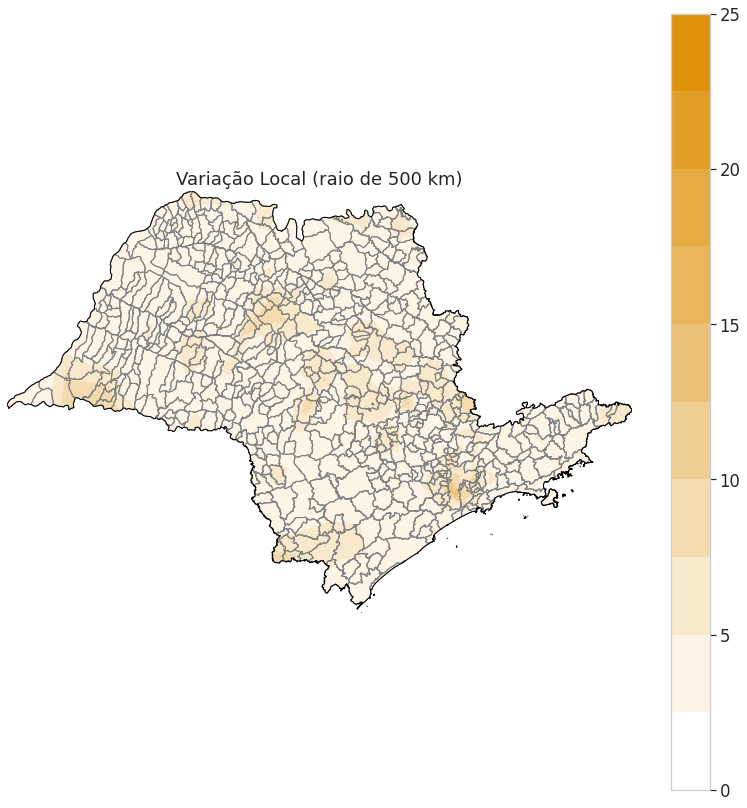

In [35]:
paleta_cores = sns.color_palette("colorblind")
with sns.axes_style("whitegrid"), sns.plotting_context('notebook', font_scale = 1.5):
    fig, ax = plt.subplots(1, 1, figsize = (14, 14))

    x = gdf_plot['Longitude']
    y = gdf_plot['Latitude']
    z = gdf_plot['Variacao_Local']

    N = 256
    cor = paleta_cores[1]
    vals = np.ones((N, 4))
    vals[:, 0] = cor[0]
    vals[:, 1] = cor[1]
    vals[:, 2] = cor[2]
    vals[:, 3] = np.linspace(0, 1, N)[::-1]
    cmap = mpl.colors.ListedColormap(vals[::-1])

    cntr = ax.tricontourf(x, y, z, levels = 10, 
                          cmap = cmap,
                          norm = mpl.colors.Normalize(vmin = z.min(), vmax = z.max(), clip = False),
                          linestyles = None, 
                          antialiased = True)
    cbar = plt.colorbar(cntr)
    
    #Limites do gráfico
    df_lim = pd.DataFrame(np.array(gdf_contorno.convex_hull.boundary.iloc[0].coords), columns = ['Longitude', 'Latitude'])
    ax.set_xlim([df_lim['Longitude'].min(), df_lim['Longitude'].max()])
    ax.set_ylim([df_lim['Latitude'].min(), df_lim['Latitude'].max()])
    #Contornos internos
    gdf_contorno_interno['geometry'].boundary.plot(ax = ax, color = 'grey', lw = 1)
    #Contornos externos
    (gdf_contorno['geometry'].envelope.difference(gdf_contorno['geometry'])).plot(ax = ax, color = 'white', edgecolor = None)
    gdf_contorno['geometry'].boundary.plot(ax = ax, color = 'black', lw = 1)
    #Remoção de Grades e Eixos
    ax.grid(False)
    frame = plt.gca()
    frame.axes.xaxis.set_ticklabels([])
    frame.axes.yaxis.set_ticklabels([])

    #ax.legend(handles = hlds, bbox_to_anchor = (1.0, 1), loc = 'upper left')
    ax.set_title('Variação Local (raio de 500 km)')

    plt.box(False)
    plt.show()

### Pontos Representativos

Os pontos de maior semelhança local, a pelo menos 500 km uns dos outros.

In [36]:
df_geocod_info = pd.read_csv(f'{path_dados_geocodificacao}/coordenadas_zonas_eleitorais_2022.csv')
df_geocod_info = df_geocod_info[['Latitude', 'Longitude', 'sigla_uf', 'nome_municipio', 'bairro']].drop_duplicates(['Latitude', 'Longitude'])

In [37]:
gdf_local_temp = gdf_local.sort_values('Semelhanca_Local', ascending = False).reset_index(drop = True).copy()
lista_pontos = []
while gdf_local_temp.shape[0] > 0:
    ponto_ref = gdf_local_temp.iloc[[0]]
    lista_pontos.append(ponto_ref)
    dist = gdf_local_temp['geometry'].distance(ponto_ref['geometry'].iloc[0])/1000
    gdf_local_temp = gdf_local_temp[dist > 500]

In [38]:
gdf_pontos = pd.concat(lista_pontos)
gdf_pontos = pd.merge(gdf_pontos, df_geocod_info, how = 'left', on = ['Latitude', 'Longitude'])
gdf_pontos

,Latitude,Longitude,Qtd,Delta_Q1,Delta_Q2,Delta_Q3,Semelhanca_Local,Variacao_Local,geometry,sigla_uf,nome_municipio,bairro
0,-9.854587,-57.813482,31.0,0.019485,0.023588,0.040930,95.907002,1.948466,POINT (-6435767.377 -1102456.618),MT,NOVA MONTE VERDE,CENTRO
1,-11.930747,-62.003042,36.0,0.022376,0.037286,0.051538,94.846187,2.237589,POINT (-6902147.063 -1337827.982),RO,ALTA FLORESTA D'OESTE,PRINCESA ISABEL
2,-8.358852,-42.252076,226.0,0.021922,0.037113,0.059629,94.037116,2.192225,POINT (-4703479.585 -933821.586),PI,SÃO JOÃO DO PIAUÍ,CENTRO
3,2.444637,-60.968519,8.0,0.022088,0.033838,0.067296,93.270410,2.208754,POINT (-6786984.49 272218.353),RR,MUCAJAÍ,CENTRO
4,-18.918916,-54.844958,90.0,0.027210,0.044587,0.067680,93.231978,2.721018,POINT (-6105312.797 -2145391.91),MS,RIO VERDE DE MATO GROSSO,NHECOLÂNDIA
5,-3.074639,-67.944971,16.0,0.035544,0.044197,0.074459,92.554069,3.554423,POINT (-7563599.574 -342431.636),AM,SANTO ANTÔNIO DO IÇÁ,SAO FRANCISCO
6,-16.442048,-51.117052,162.0,0.028697,0.046610,0.075020,92.498040,2.869730,POINT (-5690324.199 -1855971.62),GO,IPORÁ,CENTRO
7,-13.227546,-39.504585,233.0,0.029906,0.051122,0.081669,91.833102,2.990561,POINT (-4397630.286 -1485740.861),BA,MUTUÍPE,CENTRO
8,-22.151047,-51.174527,450.0,0.031921,0.052073,0.082210,91.778959,3.192110,POINT (-5696722.287 -2529669.916),SP,MARTINÓPOLIS,CENTRO
9,-3.738298,-43.357308,209.0,0.033056,0.056503,0.085187,91.481288,3.305600,POINT (-4826513.449 -416440.999),MA,CHAPADINHA,CORRENTE - ZONA URBANA


In [39]:
gdf_contorno = gdf_pais
gdf_contorno_interno = gdf_uf

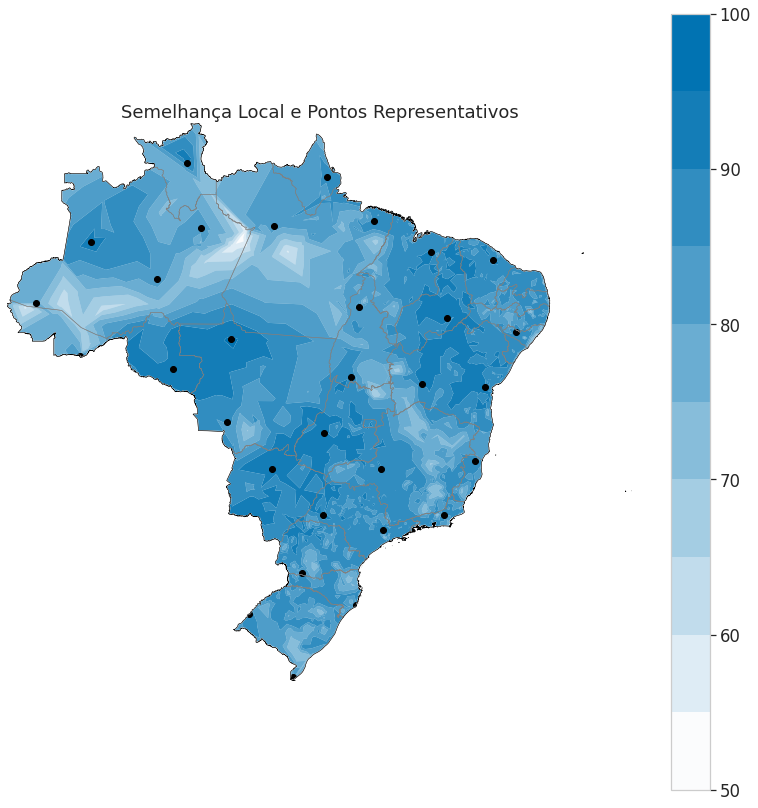

In [40]:
paleta_cores = sns.color_palette("colorblind")
with sns.axes_style("whitegrid"), sns.plotting_context('notebook', font_scale = 1.5):
    fig, ax = plt.subplots(1, 1, figsize = (14, 14))

    x = gdf_plot['Longitude']
    y = gdf_plot['Latitude']
    z = gdf_plot['Semelhanca_Local']

    N = 256
    cor = paleta_cores[0]
    vals = np.ones((N, 4))
    vals[:, 0] = cor[0]
    vals[:, 1] = cor[1]
    vals[:, 2] = cor[2]
    vals[:, 3] = np.linspace(0, 1, N)[::-1]
    cmap = mpl.colors.ListedColormap(vals[::-1])

    cntr = ax.tricontourf(x, y, z, levels = 10, 
                          cmap = cmap,
                          norm = mpl.colors.Normalize(vmin = z.min(), vmax = z.max(), clip = False),
                          linestyles = None, 
                          antialiased = True)
    cbar = plt.colorbar(cntr)

    ax.scatter(gdf_pontos['Longitude'], gdf_pontos['Latitude'], color = 'black')
    
    #Limites do gráfico
    df_lim = pd.DataFrame(np.array(gdf_contorno.convex_hull.boundary.iloc[0].coords), columns = ['Longitude', 'Latitude'])
    ax.set_xlim([df_lim['Longitude'].min(), df_lim['Longitude'].max()])
    ax.set_ylim([df_lim['Latitude'].min(), df_lim['Latitude'].max()])
    #Contornos internos
    gdf_contorno_interno['geometry'].boundary.plot(ax = ax, color = 'grey', lw = 0.5)
    #Contornos externos
    (gdf_contorno['geometry'].envelope.difference(gdf_contorno['geometry'])).plot(ax = ax, color = 'white', edgecolor = None)
    gdf_contorno['geometry'].boundary.plot(ax = ax, color = 'black', lw = 0.5)
    #Remoção de Grades e Eixos
    ax.grid(False)
    frame = plt.gca()
    frame.axes.xaxis.set_ticklabels([])
    frame.axes.yaxis.set_ticklabels([])

    #ax.legend(handles = hlds, bbox_to_anchor = (1.0, 1), loc = 'upper left')
    ax.set_title('Semelhança Local e Pontos Representativos')

    plt.box(False)
    plt.show()